In [ ]:
# Create Geolife file
import os
import pandas as pd
from src.optimized_analysis import get_prediction_for_trip
from src.process_files_geolife import labels_iterrable, get_filename_for_label_row
from src.stats import is_correct_prediction_custom_thresholds

root_path = '../data/Geolife/'
output_file_path = f'{root_path}database_metrics.csv'

rows = []
count = 0
for directory in sorted([f for f in os.listdir(root_path) if f.isdigit() and len(f) == 3]):
    user_path = f"{root_path}{directory}/"
    trajectory_path = f'{user_path}Processed_Trajectory/'
    labels_path = f'{user_path}labels.txt'

    for index, row in labels_iterrable(labels_path):
        trajectory_file = get_filename_for_label_row(row, trajectory_path)
        file_to_process = f"{trajectory_path}{trajectory_file}"
        trip_id = f"{directory}.{int(pd.to_datetime(row['Start Time']).strftime('%Y%m%d%H%M%S'))}"

        df = pd.read_csv(file_to_process,
                     skiprows=6,
                     names=['lat', 'lng', '0', 'alt', 'days_since_1899', 'date', 'time'])
        if 'timestamp' not in df.columns:
            df['timestamp'] = pd.to_datetime(df['date'] + ' ' + df['time'])
            df = df.sort_values('timestamp')
            # df = df.set_index('timestamp')

        df_copy = df.copy()
        df_copy = df_copy.set_index('timestamp')
        datapoints_bucketed_by_minute = df_copy.resample('5s').size()
        num_empty = (datapoints_bucketed_by_minute == 0).sum()
        total_buckets = len(datapoints_bucketed_by_minute)
        # sparsity = (num_empty / total_buckets) * 100 if total_buckets > 0 else 0.0
        sparsity = (num_empty / total_buckets) if total_buckets > 0 else 1.0

        number_of_records = len(df)
        if df.empty:
            total_trip_time_minutes = 0.0
            density_records_per_minute = 0.0
        else:
            total_trip_time_minutes = (df['timestamp'].iloc[-1] - df['timestamp'].iloc[0]).total_seconds() / 60
            density_records_per_minute = number_of_records / total_trip_time_minutes if total_trip_time_minutes > 0 else 0.0

        prediction = get_prediction_for_trip(df)
        actual_mode = row['Transportation Mode']
        is_prediction_correct = is_correct_prediction_custom_thresholds(prediction, actual_mode)

        count += 1
        print(f"Appending row for {trip_id} ({count} files processed)")
        rows.append({
            'trip_id': trip_id,
            'sparsity (per 5s)':  round(sparsity, 3),
            'number_of_records': number_of_records,
            'total_trip_time_minutes': round(total_trip_time_minutes, 3),
            'density_records_per_minute': round(density_records_per_minute, 3),
            'prediction': prediction,
            'actual_mode': actual_mode,
            'is_prediction_correct': is_prediction_correct
        })

dataframe = pd.DataFrame(rows)
dataframe = dataframe.set_index('trip_id')
dataframe.to_csv(output_file_path, index=True, header=True, mode='w')

print("Done!")

# 064.20080831161510
# 065.20110824135121

In [ ]:
# Create rMove database metrics file
import os
import pandas as pd
from src.map_terminology import map_to_shared_mode_names
from src.optimized_analysis import get_prediction_for_trip_rmove
from src.stats import is_correct_prediction_custom_thresholds

root_path = '../data/rMove/'
output_file_path = f'{root_path}database_metrics.csv'

locations_df = pd.read_csv(f'{root_path}Location_2023.csv')
trips_df = pd.read_csv(f'{root_path}Household_Travel_Survey_Trips_-7221806773183684102.csv', low_memory=False)
trips_df = trips_df.set_index('trip_id')

rows = []
count = 0

for trip_id, df in locations_df.groupby('tripid'):
    if trip_id not in trips_df.index:
        continue

    df = df.rename(columns={'lon': 'lng', 'collect_time': 'timestamp'})
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    df = df.sort_values('timestamp')

    # Sparsity metric
    df_copy = df.copy()
    df_copy = df_copy.set_index('timestamp')
    datapoints_bucketed_by_minute = df_copy.resample('5s').size()
    num_empty = (datapoints_bucketed_by_minute == 0).sum()
    total_buckets = len(datapoints_bucketed_by_minute)
    sparsity = (num_empty / total_buckets) if total_buckets > 0 else 1.0

    # Calculate density
    number_of_records = len(df)
    if not df.empty:
        total_trip_time_minutes = (df['timestamp'].iloc[-1] - df['timestamp'].iloc[0]).total_seconds() / 60
        density_records_per_minute = number_of_records / total_trip_time_minutes if total_trip_time_minutes > 0 else 0.0
    else:
        total_trip_time_minutes = 0.0
        density_records_per_minute = 0.0

    # Generate prediction and compare to actual mode
    prediction = get_prediction_for_trip_rmove(df)
    trip_info = trips_df.loc[trip_id]
    actual_mode = trip_info['mode_1']
    mapped_prediction = map_to_shared_mode_names(prediction)
    mapped_actual = map_to_shared_mode_names(actual_mode)
    is_prediction_correct = is_correct_prediction_custom_thresholds(mapped_prediction, mapped_actual)

    count += 1
    print(f"Appending row for {trip_id} ({count} files processed)")
    rows.append({
        'trip_id': trip_id,
        'sparsity (per 5s)': round(sparsity, 3),
        'number_of_records': number_of_records,
        'total_trip_time_minutes': round(total_trip_time_minutes, 3),
        'density_records_per_minute': round(density_records_per_minute, 3),
        'prediction': mapped_prediction,
        'actual_mode': mapped_actual,
        'is_prediction_correct': is_prediction_correct
    })

dataframe = pd.DataFrame(rows)
dataframe = dataframe.set_index('trip_id')
dataframe.to_csv(output_file_path, index=True, header=True, mode='w')

print("Done!")
print(f"Trips processed: {count}")

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

root_path = '../data/'
file_name = 'database_metrics.csv'

df_geolife = pd.read_csv(f'{root_path}Geolife/{file_name}')
df_rmove = pd.read_csv(f'{root_path}rMove/{file_name}')

# print(df_geolife.head())
# print(df_rmove.head())

print("\nTotal percentage correct and incorrect")
geolife_num_correct = df_geolife['is_prediction_correct'].sum()
geolife_percent_correct = geolife_num_correct / len(df_geolife)
print(f'Geolife correctness: {round(geolife_percent_correct, 3) * 100}% (n_correct={geolife_num_correct})')

rmove_num_correct = df_rmove['is_prediction_correct'].sum()
rmove_percent_correct = rmove_num_correct / len(df_rmove)
print(f'rMove correctness: {round(rmove_percent_correct, 3) * 100}% (n_correct={rmove_num_correct})')

print("\nTotal percentage correct and incorrect when ignoring trips with <= 2 datapoint")
df_geolife_short_trips_removed = df_geolife[df_geolife['number_of_records'] > 2]
geolife_adjusted_num_correct = df_geolife_short_trips_removed['is_prediction_correct'].sum()
geolife_adjusted_percent_correct = geolife_adjusted_num_correct / len(df_geolife_short_trips_removed)
print(f'Geolife adjusted correctness: {round(geolife_adjusted_percent_correct, 3) * 100}% (n_correct={geolife_adjusted_num_correct})')

df_rmove_short_trips_removed = df_rmove[df_rmove['number_of_records'] > 2]
rmove_adjusted_num_correct = df_rmove_short_trips_removed['is_prediction_correct'].sum()
rmove_adjusted_percent_correct = rmove_adjusted_num_correct / len(df_rmove_short_trips_removed)
print(f'rMove adjusted correctness: {round(rmove_adjusted_percent_correct, 3) * 100}% (n_correct={rmove_adjusted_num_correct})')


Total percentage correct and incorrect
Geolife correctness: 40.9% (n_correct=6026)
rMove correctness: 38.6% (n_correct=21858)

Total percentage correct and incorrect when ignoring trips with <= 2 datapoint
Geolife adjusted correctness: 63.1% (n_correct=6026)
rMove adjusted correctness: 58.4% (n_correct=21858)


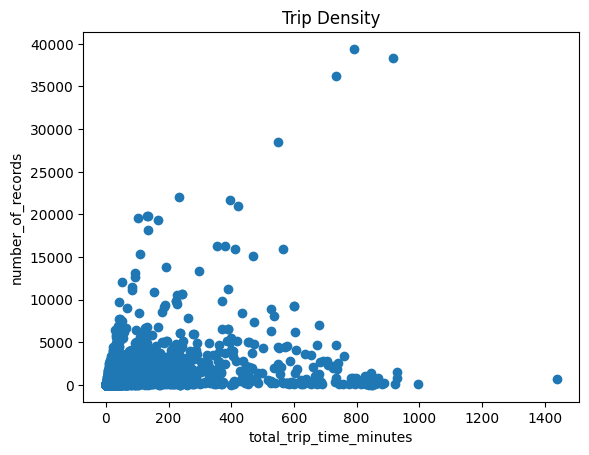

In [19]:
plt.scatter(df_geolife['total_trip_time_minutes'], df_geolife['number_of_records'])
plt.xlabel('total_trip_time_minutes')
plt.ylabel('number_of_records')
plt.title('Trip Density')
plt.show()

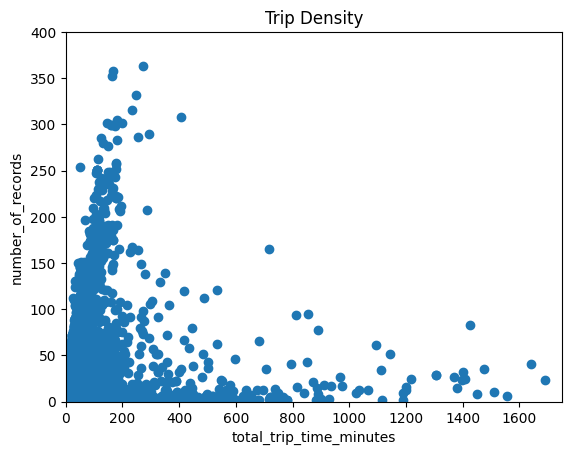

In [4]:
plt.scatter(df_rmove['total_trip_time_minutes'], df_rmove['number_of_records'])
plt.xlabel('total_trip_time_minutes')
plt.ylabel('number_of_records')
plt.title('Trip Density')

plt.xlim(0, 1750)
plt.ylim(0, 400)

plt.show()

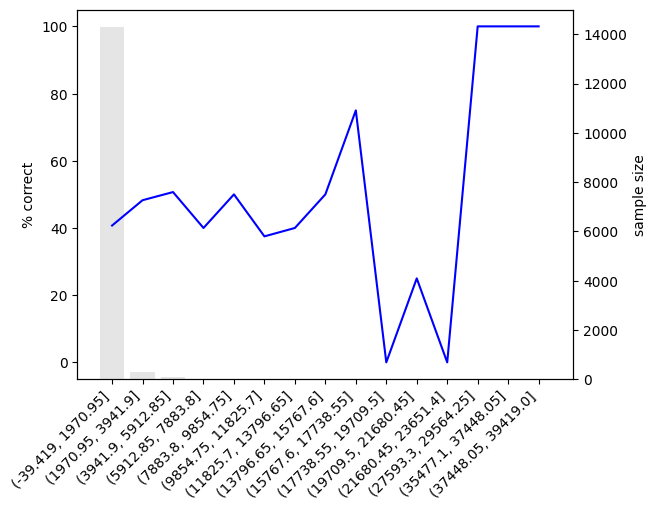

In [45]:
import pandas as pd

df_geolife['num_records_bin'] = pd.cut(df_geolife['number_of_records'], bins=20)

# 2. Calculate % correct (True) per bin
binned = df_geolife.groupby('num_records_bin')['is_prediction_correct'].mean() * 100

# 3. Plot
fig, ax1 = plt.subplots()

# Bar chart for sample size on a secondary y-axis
ax2 = ax1.twinx()
ax2.bar(range(len(binned)), df_geolife.groupby('num_records_bin')['is_prediction_correct'].count(),
        alpha=0.2, color='grey')
ax2.set_ylabel('sample size')

# Line chart for % correct on primary y-axis
ax1.plot(range(len(binned)), binned.values, color='blue')
ax1.set_xticks(range(len(binned)))
ax1.set_xticklabels(binned.index.astype(str), rotation=45, ha='right')
ax1.set_ylabel('% correct')
ax1.set_zorder(ax2.get_zorder() + 1)  # bring line to front
ax1.patch.set_visible(False)  # make ax1 background transparent so ax2 shows through

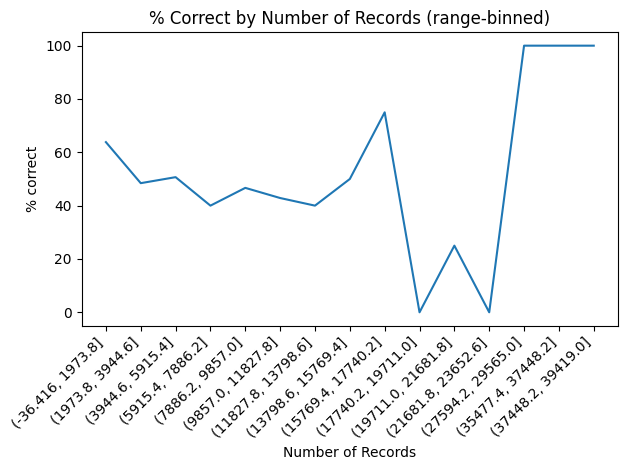

In [37]:
import pandas as pd

df_geolife_short_trips_removed['num_records_bin'] = pd.cut(df_geolife_short_trips_removed['number_of_records'], bins=20)

# 2. Calculate % correct (True) per bin
binned = df_geolife_short_trips_removed.groupby('num_records_bin')['is_prediction_correct'].mean() * 100

# 3. Plot
plt.plot(range(len(binned)), binned.values)
plt.xticks(range(len(binned)), [str(b) for b in binned.index], rotation=45, ha='right')
plt.xlabel('Number of Records')
plt.ylabel('% correct')
plt.title('% Correct by Number of Records (range-binned)')
plt.tight_layout()
plt.show()

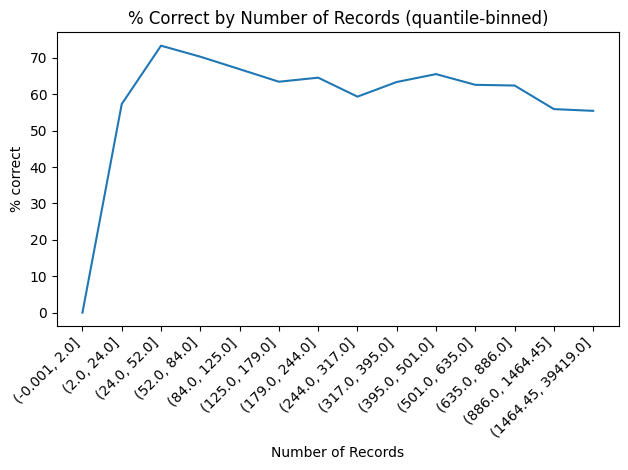

In [39]:
import pandas as pd

df_geolife['num_records_bin'] = pd.qcut(df_geolife['number_of_records'], q=20, duplicates='drop')

# 2. Calculate % correct (True) per bin
binned = df_geolife.groupby('num_records_bin')['is_prediction_correct'].mean() * 100

# 3. Plot
plt.plot(range(len(binned)), binned.values)
plt.xticks(range(len(binned)), [str(b) for b in binned.index], rotation=45, ha='right')
plt.xlabel('Number of Records')
plt.ylabel('% correct')
plt.title('% Correct by Number of Records (quantile-binned)')
plt.tight_layout()
plt.show()

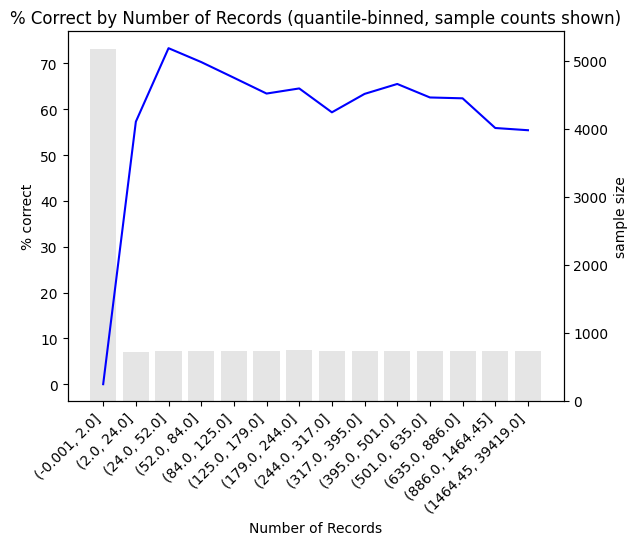

In [49]:
import pandas as pd

df_geolife['num_records_bin'] = pd.qcut(df_geolife['number_of_records'], q=20, duplicates='drop')

# 2. Calculate % correct (True) per bin
binned = df_geolife.groupby('num_records_bin')['is_prediction_correct'].mean() * 100

# 3. Plot
fig, ax1 = plt.subplots()

# Bar chart for sample size on a secondary y-axis
ax2 = ax1.twinx()
ax2.bar(range(len(binned)), df_geolife.groupby('num_records_bin')['is_prediction_correct'].count(),
        alpha=0.2, color='grey')
ax2.set_ylabel('sample size')

# Line chart for % correct on primary y-axis
ax1.plot(range(len(binned)), binned.values, color='blue')
ax1.set_xticks(range(len(binned)))
ax1.set_xticklabels(binned.index.astype(str), rotation=45, ha='right')
ax1.set_xlabel('Number of Records')
ax1.set_ylabel('% correct')
plt.title('% Correct by Number of Records (quantile-binned, sample counts shown)')
ax1.set_zorder(ax2.get_zorder() + 1)  # bring line to front
ax1.patch.set_visible(False)  # make ax1 background transparent so ax2 shows through

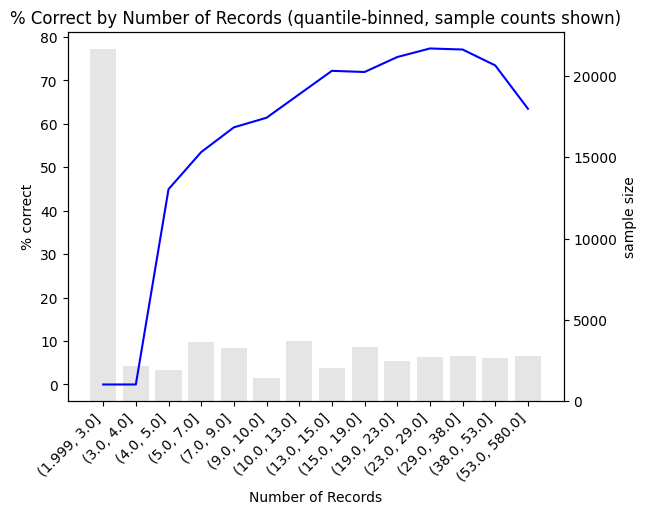

In [50]:
import pandas as pd

df_rmove['num_records_bin'] = pd.qcut(df_rmove['number_of_records'], q=20, duplicates='drop')

# 2. Calculate % correct (True) per bin
binned = df_rmove.groupby('num_records_bin')['is_prediction_correct'].mean() * 100

# 3. Plot
fig, ax1 = plt.subplots()

# Bar chart for sample size on a secondary y-axis
ax2 = ax1.twinx()
ax2.bar(range(len(binned)), df_rmove.groupby('num_records_bin')['is_prediction_correct'].count(),
        alpha=0.2, color='grey')
ax2.set_ylabel('sample size')

# Line chart for % correct on primary y-axis
ax1.plot(range(len(binned)), binned.values, color='blue')
ax1.set_xticks(range(len(binned)))
ax1.set_xticklabels(binned.index.astype(str), rotation=45, ha='right')
ax1.set_xlabel('Number of Records')
ax1.set_ylabel('% correct')
plt.title('% Correct by Number of Records (quantile-binned, sample counts shown)')
ax1.set_zorder(ax2.get_zorder() + 1)  # bring line to front
ax1.patch.set_visible(False)  # make ax1 background transparent so ax2 shows through

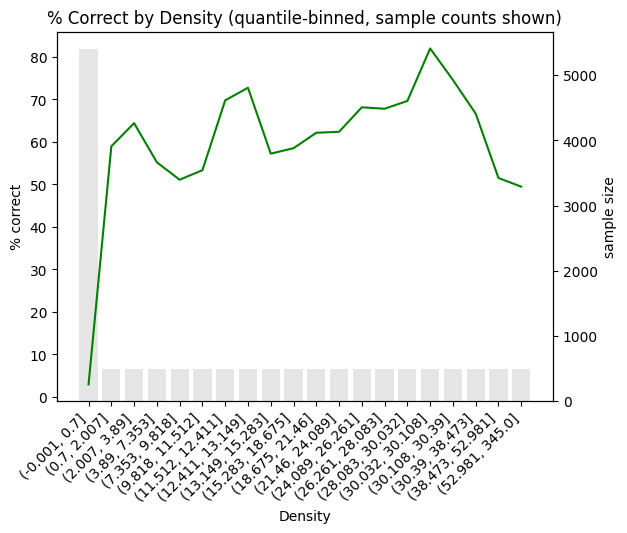

In [70]:
import pandas as pd

df_geolife['density_bin'] = pd.qcut(df_geolife['density_records_per_minute'], q=30, duplicates='drop')

# 2. Calculate % correct (True) per bin
binned = df_geolife.groupby('density_bin')['is_prediction_correct'].mean() * 100

# 3. Plot
fig, ax1 = plt.subplots()

# Bar chart for sample size on a secondary y-axis
ax2 = ax1.twinx()
ax2.bar(range(len(binned)), df_geolife.groupby('density_bin')['is_prediction_correct'].count(),
        alpha=0.2, color='grey')
ax2.set_ylabel('sample size')

# Line chart for % correct on primary y-axis
ax1.plot(range(len(binned)), binned.values, color='green')
ax1.set_xticks(range(len(binned)))
ax1.set_xticklabels(binned.index.astype(str), rotation=45, ha='right')
ax1.set_xlabel('Density')
ax1.set_ylabel('% correct')
plt.title('% Correct by Density (quantile-binned, sample counts shown)')
ax1.set_zorder(ax2.get_zorder() + 1)  # bring line to front
ax1.patch.set_visible(False)  # make ax1 background transparent so ax2 shows through

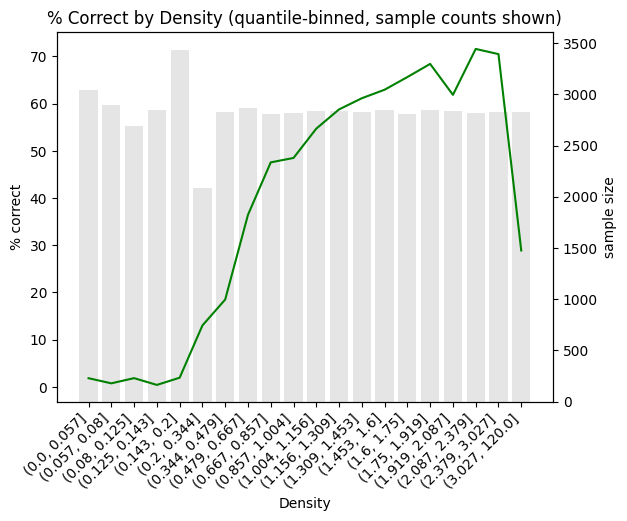

In [68]:
import pandas as pd

df_rmove['density_bin'] = pd.qcut(df_rmove['density_records_per_minute'], q=20, duplicates='drop')

# 2. Calculate % correct (True) per bin
binned = df_rmove.groupby('density_bin')['is_prediction_correct'].mean() * 100

# 3. Plot
fig, ax1 = plt.subplots()

# Bar chart for sample size on a secondary y-axis
ax2 = ax1.twinx()
ax2.bar(range(len(binned)), df_rmove.groupby('density_bin')['is_prediction_correct'].count(),
        alpha=0.2, color='grey')
ax2.set_ylabel('sample size')

# Line chart for % correct on primary y-axis
ax1.plot(range(len(binned)), binned.values, color='green')
ax1.set_xticks(range(len(binned)))
ax1.set_xticklabels(binned.index.astype(str), rotation=45, ha='right')
ax1.set_xlabel('Density')
ax1.set_ylabel('% correct')
plt.title('% Correct by Density (quantile-binned, sample counts shown)')
ax1.set_zorder(ax2.get_zorder() + 1)  # bring line to front
ax1.patch.set_visible(False)  # make ax1 background transparent so ax2 shows through

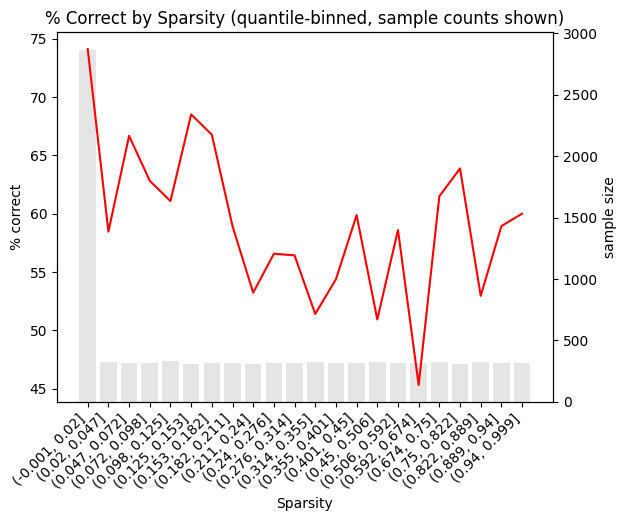

In [128]:
import pandas as pd

df_geolife_short_trips_removed['sparsity_bin'] = pd.qcut(df_geolife_short_trips_removed['sparsity (per 5s)'], q=30, duplicates='drop')

# 2. Calculate % correct (True) per bin
binned = df_geolife_short_trips_removed.groupby('sparsity_bin')['is_prediction_correct'].mean() * 100

# 3. Plot
fig, ax1 = plt.subplots()

# Bar chart for sample size on a secondary y-axis
ax2 = ax1.twinx()
ax2.bar(range(len(binned)), df_geolife_short_trips_removed.groupby('sparsity_bin')['is_prediction_correct'].count(),
        alpha=0.2, color='grey')
ax2.set_ylabel('sample size')

# Line chart for % correct on primary y-axis
ax1.plot(range(len(binned)), binned.values, color='red')
ax1.set_xticks(range(len(binned)))
ax1.set_xticklabels(binned.index.astype(str), rotation=45, ha='right')
ax1.set_xlabel('Sparsity')
ax1.set_ylabel('% correct')
plt.title('% Correct by Sparsity (quantile-binned, sample counts shown)')
ax1.set_zorder(ax2.get_zorder() + 1)  # bring line to front
ax1.patch.set_visible(False)  # make ax1 background transparent so ax2 shows through

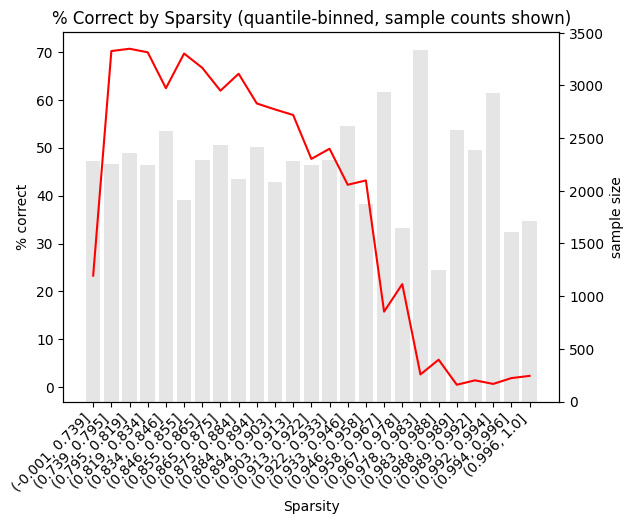

In [98]:
import pandas as pd

df_rmove['sparsity_bin'] = pd.qcut(df_rmove['sparsity (per 5s)'], q=25, duplicates='drop')

# 2. Calculate % correct (True) per bin
binned = df_rmove.groupby('sparsity_bin')['is_prediction_correct'].mean() * 100

# 3. Plot
fig, ax1 = plt.subplots()

# Bar chart for sample size on a secondary y-axis
ax2 = ax1.twinx()
ax2.bar(range(len(binned)), df_rmove.groupby('sparsity_bin')['is_prediction_correct'].count(),
        alpha=0.2, color='grey')
ax2.set_ylabel('sample size')

# Line chart for % correct on primary y-axis
ax1.plot(range(len(binned)), binned.values, color='red')
ax1.set_xticks(range(len(binned)))
ax1.set_xticklabels(binned.index.astype(str), rotation=45, ha='right')
ax1.set_xlabel('Sparsity')
ax1.set_ylabel('% correct')
plt.title('% Correct by Sparsity (quantile-binned, sample counts shown)')
ax1.set_zorder(ax2.get_zorder() + 1)  # bring line to front
ax1.patch.set_visible(False)  # make ax1 background transparent so ax2 shows through

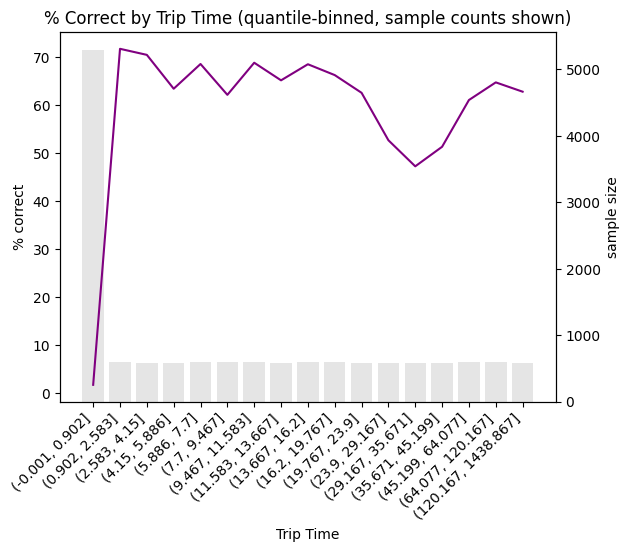

In [107]:
import pandas as pd

df_geolife['trip_time_bin'] = pd.qcut(df_geolife['total_trip_time_minutes'], q=25, duplicates='drop')

# 2. Calculate % correct (True) per bin
binned = df_geolife.groupby('trip_time_bin')['is_prediction_correct'].mean() * 100

# 3. Plot
fig, ax1 = plt.subplots()

# Bar chart for sample size on a secondary y-axis
ax2 = ax1.twinx()
ax2.bar(range(len(binned)), df_geolife.groupby('trip_time_bin')['is_prediction_correct'].count(),
        alpha=0.2, color='grey')
ax2.set_ylabel('sample size')

# Line chart for % correct on primary y-axis
ax1.plot(range(len(binned)), binned.values, color='purple')
ax1.set_xticks(range(len(binned)))
ax1.set_xticklabels(binned.index.astype(str), rotation=45, ha='right')
ax1.set_xlabel('Trip Time')
ax1.set_ylabel('% correct')
plt.title('% Correct by Trip Time (quantile-binned, sample counts shown)')
ax1.set_zorder(ax2.get_zorder() + 1)  # bring line to front
ax1.patch.set_visible(False)  # make ax1 background transparent so ax2 shows through

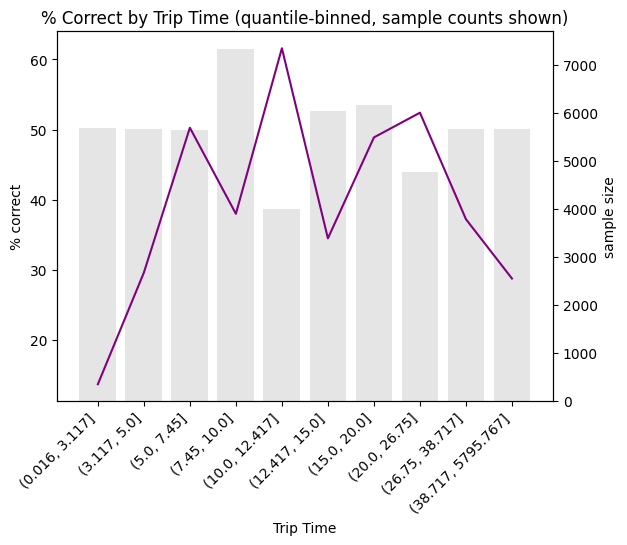

In [130]:
import pandas as pd

df_rmove['trip_time_bin'] = pd.qcut(df_rmove['total_trip_time_minutes'], q=10, duplicates='drop')

# 2. Calculate % correct (True) per bin
binned = df_rmove.groupby('trip_time_bin')['is_prediction_correct'].mean() * 100

# 3. Plot
fig, ax1 = plt.subplots()

# Bar chart for sample size on a secondary y-axis
ax2 = ax1.twinx()
ax2.bar(range(len(binned)), df_rmove.groupby('trip_time_bin')['is_prediction_correct'].count(),
        alpha=0.2, color='grey')
ax2.set_ylabel('sample size')

# Line chart for % correct on primary y-axis
ax1.plot(range(len(binned)), binned.values, color='purple')
ax1.set_xticks(range(len(binned)))
ax1.set_xticklabels(binned.index.astype(str), rotation=45, ha='right')
ax1.set_xlabel('Trip Time')
ax1.set_ylabel('% correct')
plt.title('% Correct by Trip Time (quantile-binned, sample counts shown)')
ax1.set_zorder(ax2.get_zorder() + 1)  # bring line to front
ax1.patch.set_visible(False)  # make ax1 background transparent so ax2 shows through

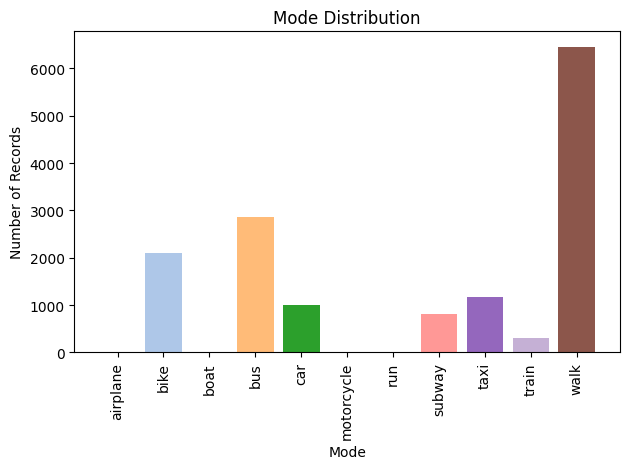

In [118]:
# Look at distributions of actual travel mode across time, distance, density, sparsity

counts_per_mode = df_geolife['actual_mode'].value_counts().sort_index()

plt.bar(counts_per_mode.index, counts_per_mode.values, color=plt.cm.tab20.colors[:len(counts_per_mode)])
plt.xlabel('Mode')
plt.xticks(rotation=90)
plt.ylabel('Number of Records')
plt.title('Mode Distribution')
plt.tight_layout()
plt.show()

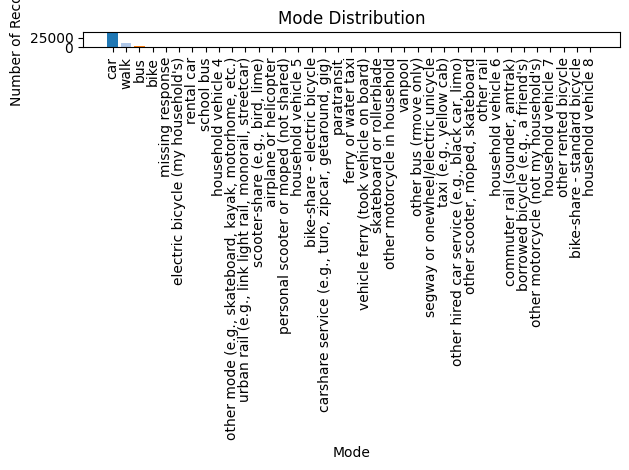

In [131]:
# Look at distributions of actual travel mode across time, distance, density, sparsity
modes_to_include = ['walk', 'bike', 'car', 'bus']

# counts_per_mode = df_rmove[df_rmove['actual_mode'].isin(modes_to_include)]['actual_mode'].value_counts()
counts_per_mode = df_rmove['actual_mode'].value_counts()


plt.bar(counts_per_mode.index, counts_per_mode.values, color=plt.cm.tab20.colors[:len(counts_per_mode)])
plt.xlabel('Mode')
plt.xticks(rotation=90)
plt.ylabel('Number of Records')
plt.title('Mode Distribution')
plt.tight_layout()
plt.show()